# `physisorption`

Simulates a gas-physisorption isotherm (adsorption + desorption) on a binary image of a porous medium, reproducing the hallmark hysteresis loop seen in BET-style nitrogen sorption experiments.

At each pressure step, two physical models are stitched together:

1. **Harkins-Jura** maps the statistical adsorbed-film thickness to a relative pressure $p/p_0$.
2. **Kelvin-Cohan** maps that pressure to the radius at which capillary condensation occurs in cylindrical pores.

A morphological closing of the void space by the capillary radius identifies the regions that are condensed at each step. The desorption branch is recovered by tracking which condensed regions remain connected to the image boundary as the film shrinks back.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import porespy as ps
from porespy.beta import physisorption

ps.visualization.set_mpl_style()

## Generate a porous medium

We use `blobs` to produce a 2D structure with a mix of pore sizes, then `fill_invalid_pores` to remove isolated pockets that the simulation cannot reach from the boundary.

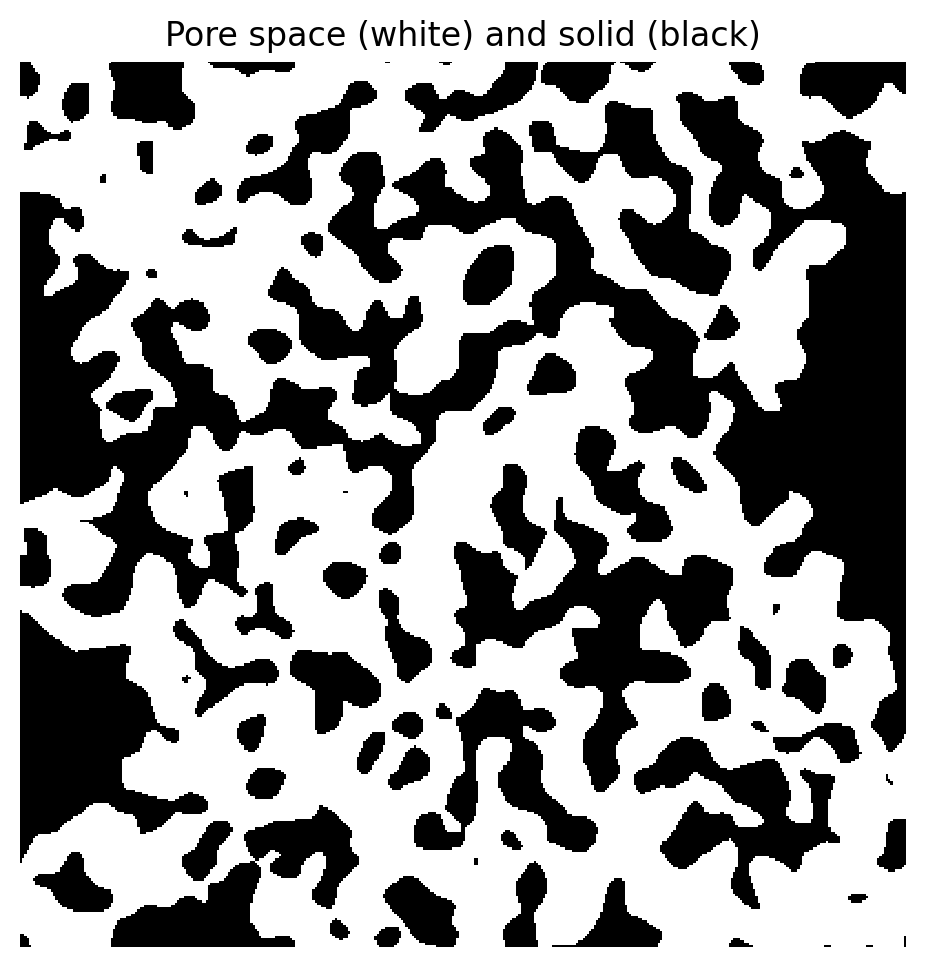

In [2]:
im = ps.generators.blobs(
    shape=[400, 400], porosity=0.6, blobiness=2.0, seed=0,
)
im = ps.filters.fill_invalid_pores(im)

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(im, origin='lower', cmap='gray')
ax.set_title('Pore space (white) and solid (black)')
ax.axis(False);

## Run the simulation

The defaults are tuned for nitrogen at 77 K (the workhorse of BET porosimetry). `voxel_size` ties the image to a physical scale; here each voxel is 0.5 nm wide, putting the pore sizes in the mesoporous range where capillary condensation produces a visible hysteresis loop.

In [3]:
bet = physisorption(im, voxel_size=0.5)
print(f'Adsorption steps: {bet.V_ads.size}')
print(f'Desorption steps: {bet.V_des.size}')
print(f'Pressure range: {bet.p_ads.min():.3f} to {bet.p_ads.max():.3f}')

adsorption:   0%|          | 0/9 [00:00<?, ?it/s]

desorption:   0%|          | 0/9 [00:00<?, ?it/s]

Adsorption steps: 9
Desorption steps: 9
Pressure range: 0.298 to 0.998


## The isotherm

Plotting condensed volume against $p/p_0$ for both branches gives the classic hysteresis loop. The adsorption branch fills pores progressively from narrow to wide; the desorption branch lags because liquid in a wide pore can only escape through the narrowest connection back to the surface.

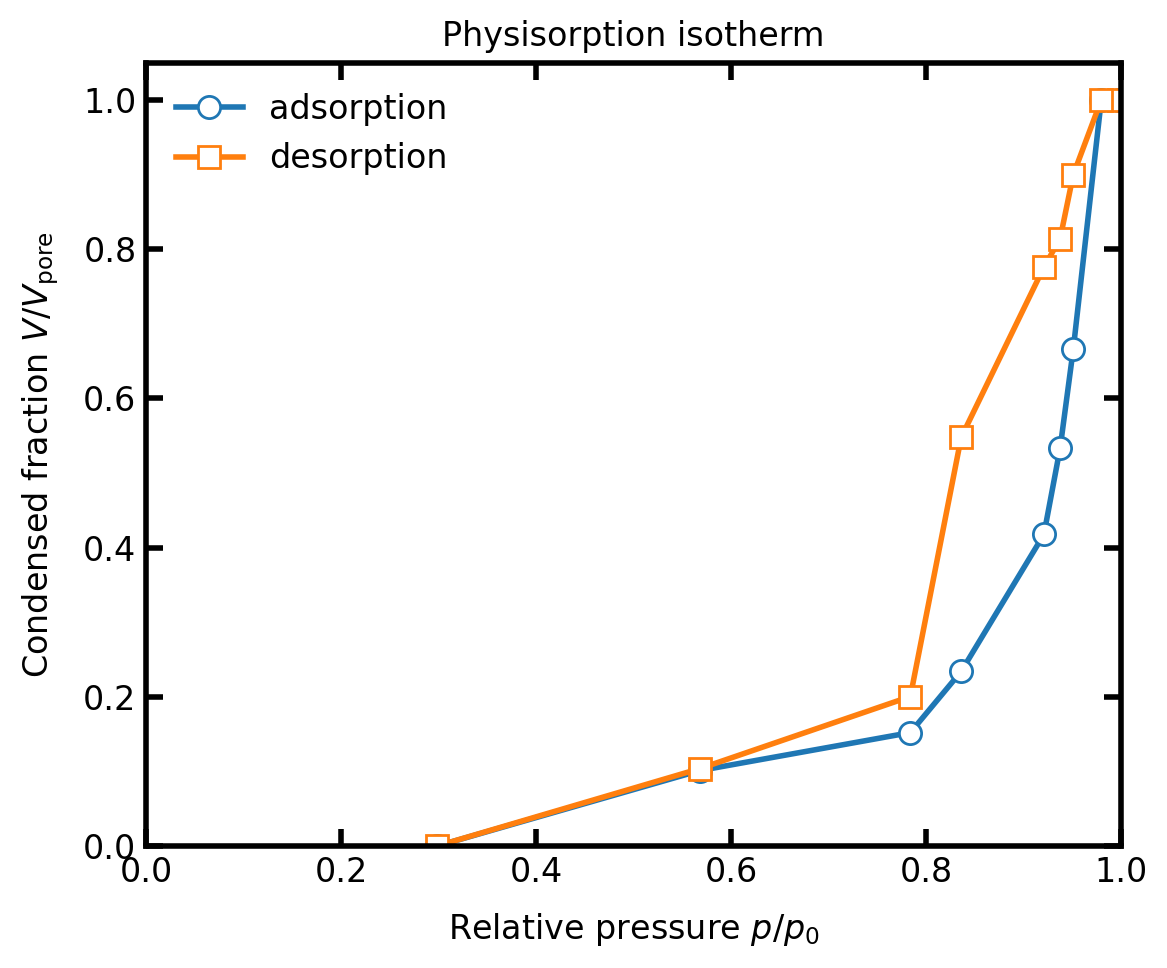

In [4]:
V_pore = im.sum()
fig, ax = plt.subplots(figsize=[6, 5])
ax.plot(bet.p_ads, bet.V_ads / V_pore, 'o-', label='adsorption')
ax.plot(bet.p_des, bet.V_des / V_pore, 's-', label='desorption')
ax.set_xlabel('Relative pressure $p/p_0$')
ax.set_ylabel(r'Condensed fraction $V/V_\mathrm{pore}$')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Physisorption isotherm');

## Where each pore fills

`im_ads` records, for each voxel, the film thickness (in nm) at which it became part of the condensed phase. Visualising it as a heat map shows the size hierarchy of the pore network: narrow throats fill at low thickness (dark), wide chambers at high thickness (bright).

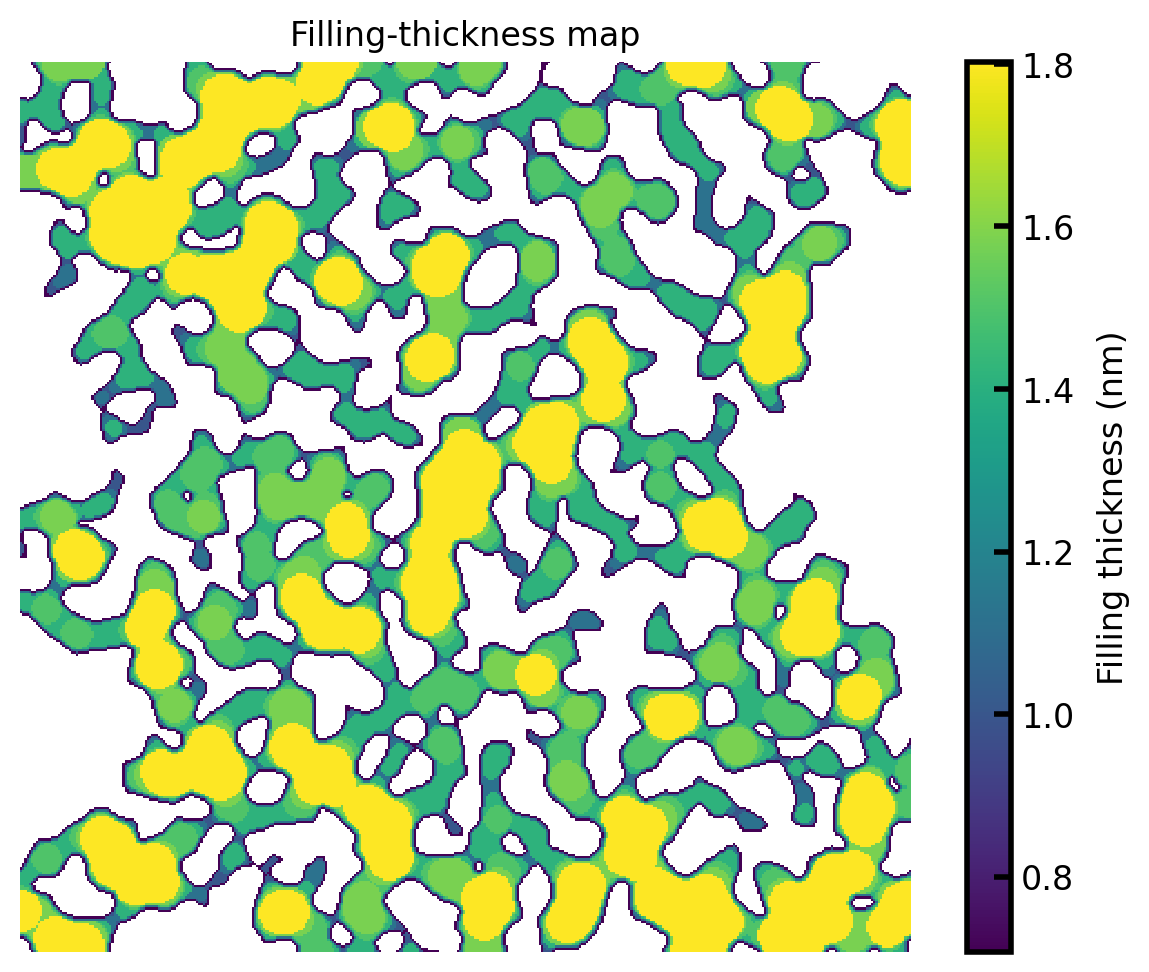

In [5]:
fig, ax = plt.subplots(figsize=[6, 5])
im_ads_view = np.where(im, bet.im_ads, np.nan)
h = ax.imshow(im_ads_view, origin='lower', cmap='viridis')
fig.colorbar(h, ax=ax, label='Filling thickness (nm)')
ax.set_title('Filling-thickness map')
ax.axis(False);

## Snapshots along the adsorption branch

Stepping through a few relative pressures shows the pore-filling sequence directly. As $p/p_0$ rises, larger and larger pores capillary-condense.

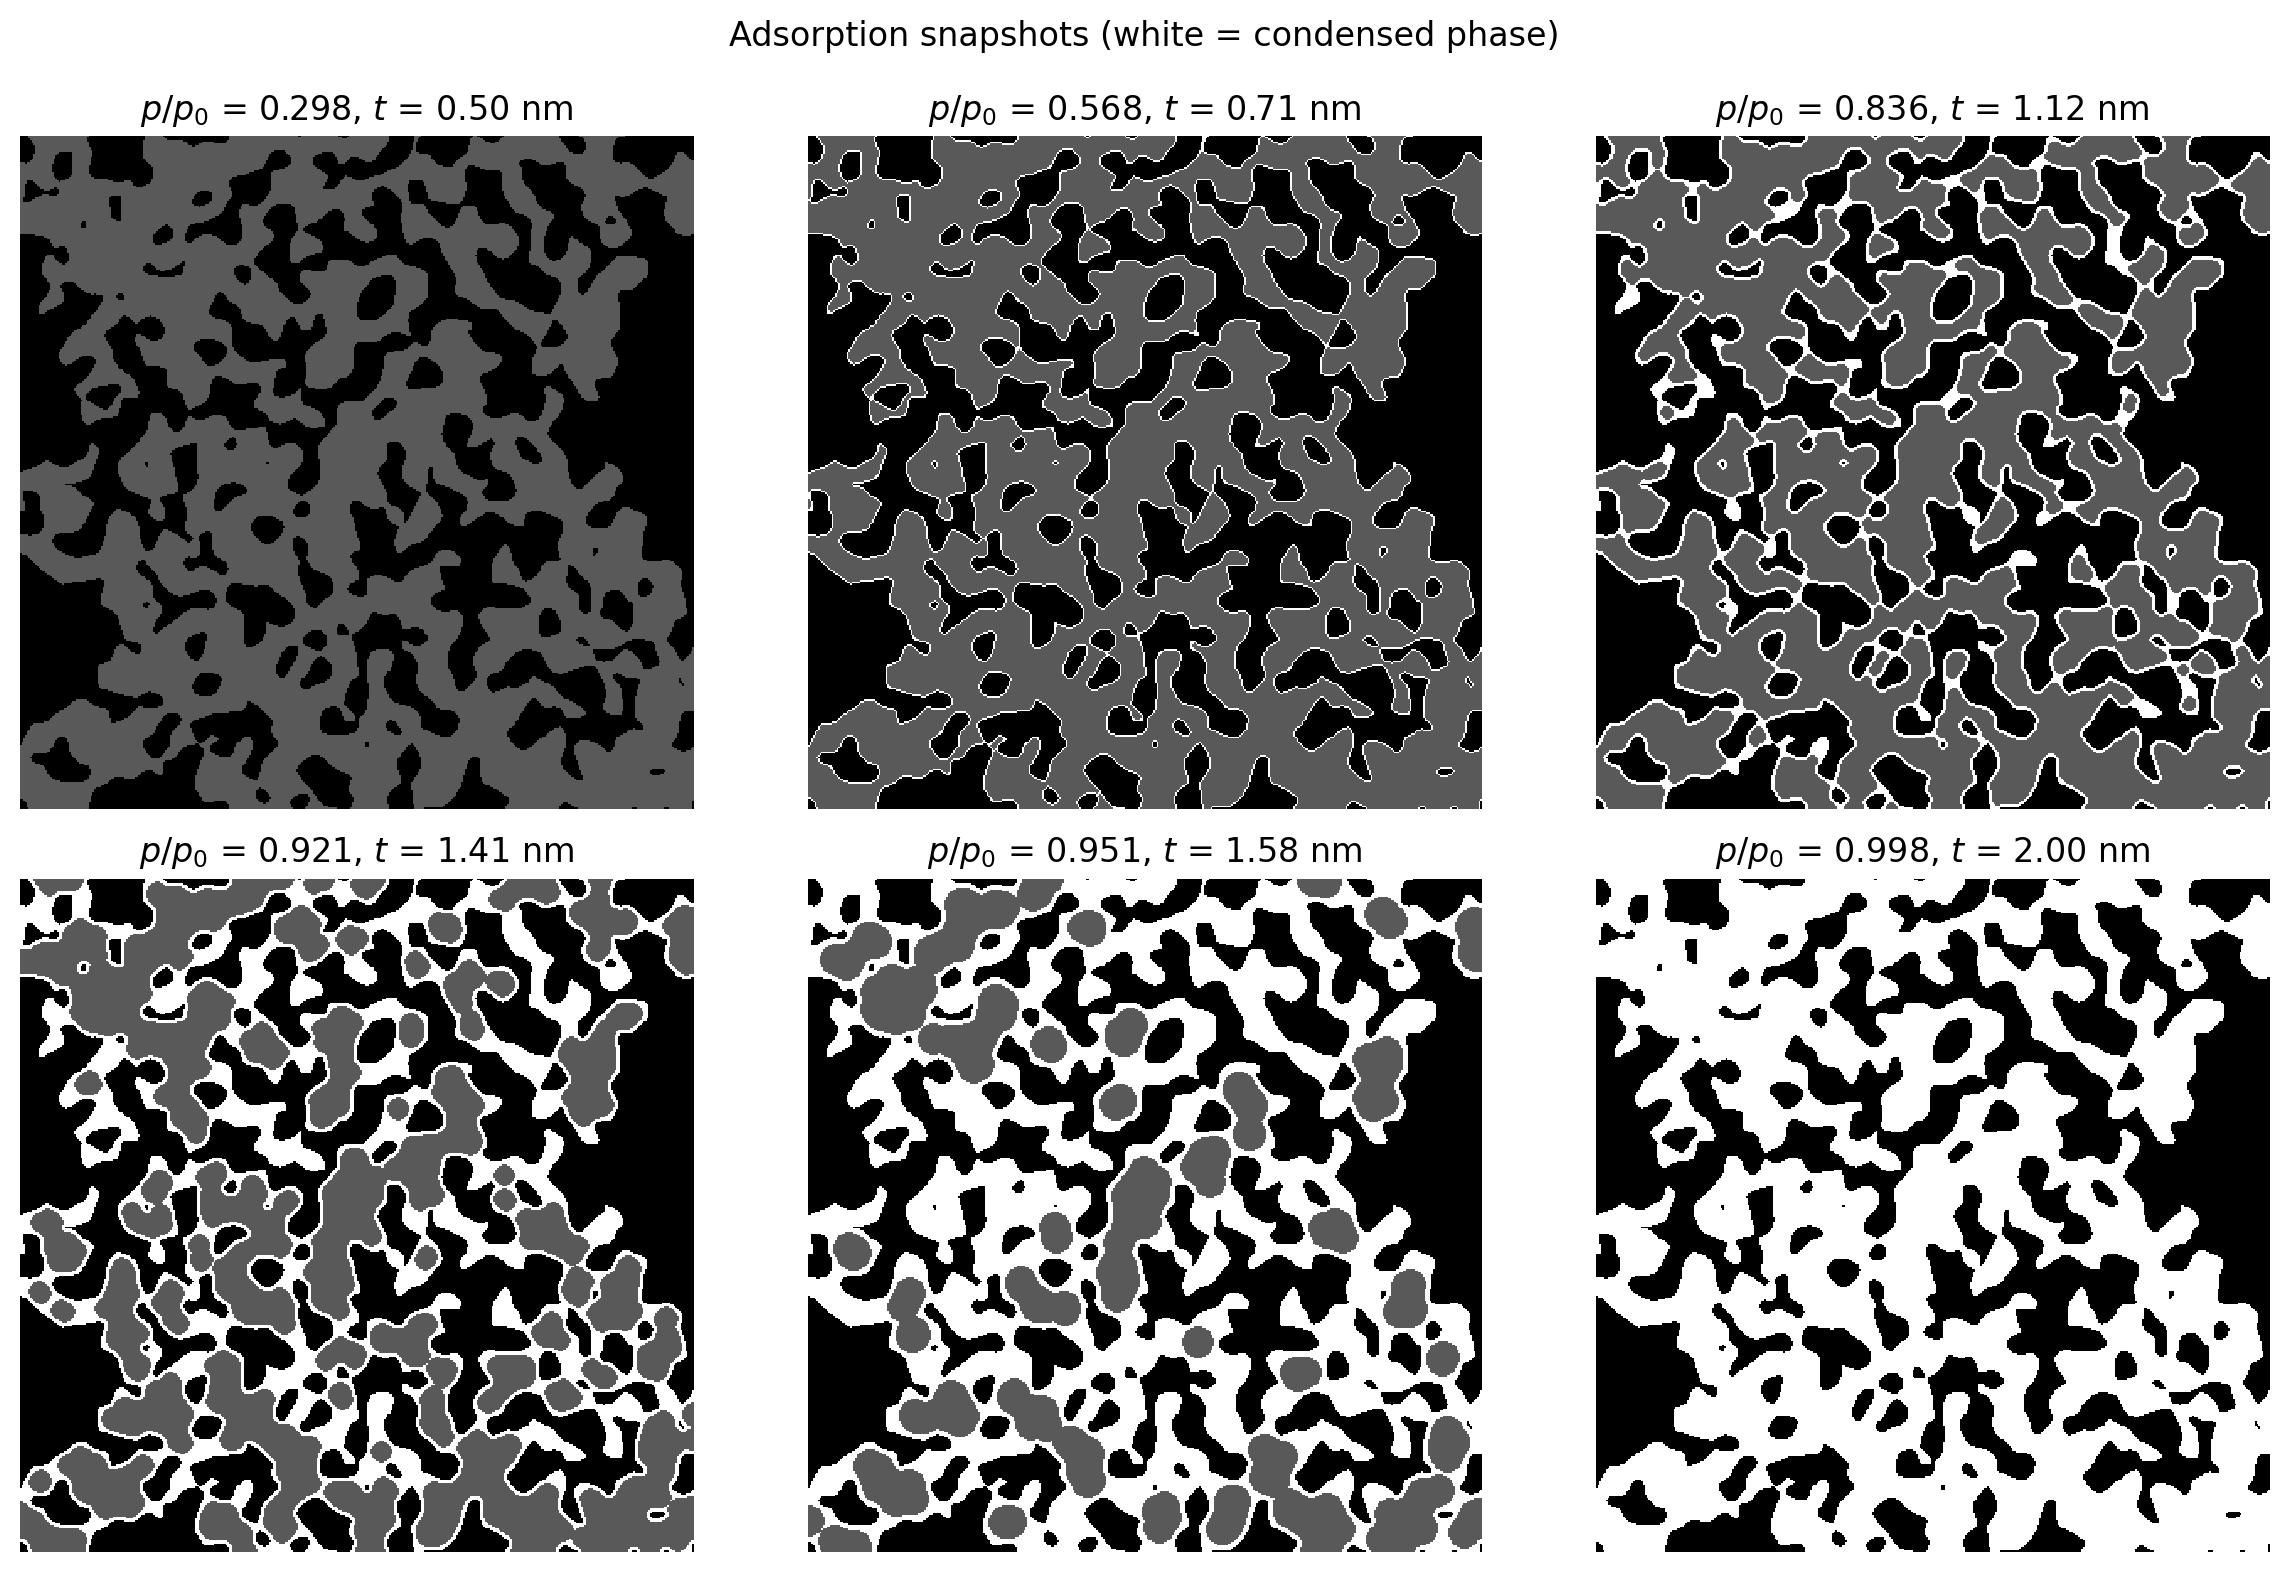

In [6]:
n_snap = 6
indices = np.linspace(0, bet.t_ads.size - 1, n_snap).astype(int)
fig, axes = plt.subplots(2, 3, figsize=[12, 8])
for ax, idx in zip(axes.ravel(), indices):
    t = bet.t_ads[idx]
    p = bet.p_ads[idx]
    snap = np.zeros_like(im, dtype=float)
    snap[im] = 0.35  # vapor-filled pore
    condensed = (bet.im_ads > 0) & (bet.im_ads <= t) & im
    snap[condensed] = 1.0
    ax.imshow(snap, origin='lower', cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'$p/p_0$ = {p:.3f}, $t$ = {t:.2f} nm')
    ax.axis(False)
fig.suptitle('Adsorption snapshots (white = condensed phase)')
fig.tight_layout();

## Trying a different fluid

The defaults are nitrogen-at-77 K, but the parameters are exposed: supply your own surface tension, molar volume, temperature, and Harkins-Jura coefficients. Below is argon-at-87 K for comparison; the isotherm shifts because argon condenses at a different Kelvin radius for the same pressure.

adsorption:   0%|          | 0/9 [00:00<?, ?it/s]

desorption:   0%|          | 0/9 [00:00<?, ?it/s]

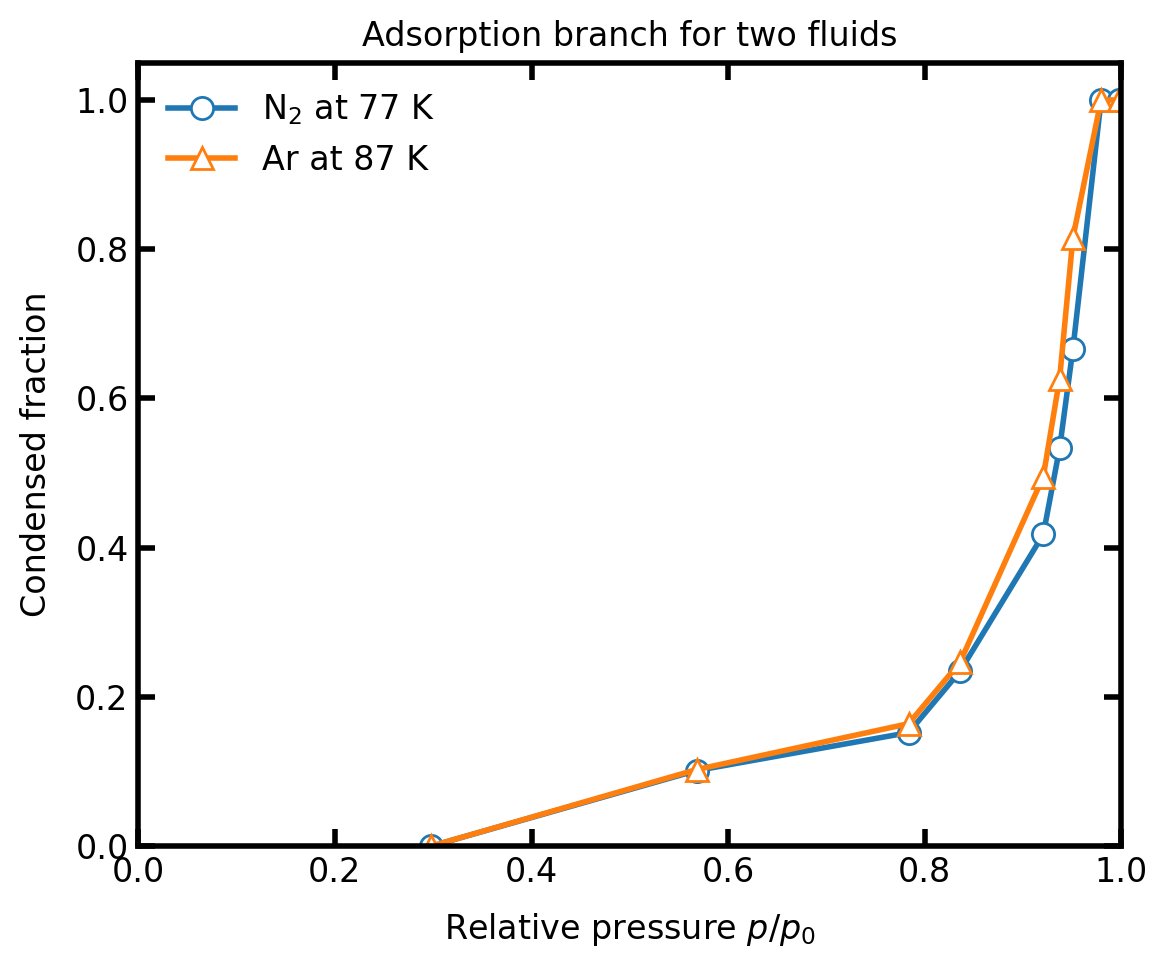

In [7]:
bet_ar = physisorption(
    im, voxel_size=0.5, T=87.0, gamma=0.0125, vm=28.6e-6,
)

fig, ax = plt.subplots(figsize=[6, 5])
ax.plot(bet.p_ads, bet.V_ads / V_pore, 'o-', label='N$_2$ at 77 K')
ax.plot(bet_ar.p_ads, bet_ar.V_ads / V_pore,
        '^-', label='Ar at 87 K')
ax.set_xlabel('Relative pressure $p/p_0$')
ax.set_ylabel('Condensed fraction')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Adsorption branch for two fluids');